8A Outlier detection with LOF

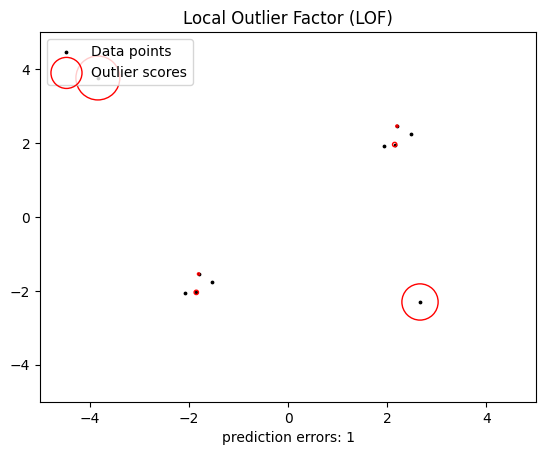

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
np.random.seed(42)
# Generate train data
X_inliers = 0.3 * np.random.randn(4, 2) #100 4 -smaples
X_inliers = np.r_[X_inliers + 2, X_inliers - 2]
# Generate some outliers
X_outliers = np.random.uniform(low=-4, high=4, size=(2, 2)) #20
X = np.r_[X_inliers, X_outliers]
n_outliers = len(X_outliers)
ground_truth = np.ones(len(X), dtype=int)
ground_truth[-n_outliers:] = -1
# fit the model for outlier detection (default)
clf = LocalOutlierFactor(n_neighbors=3, contamination=0.1)
# use fit_predict to compute the predicted labels of the training samples
# (when LOF is used for outlier detection, the estimator has no predict,
# decision_function and score_samples methods).
y_pred = clf.fit_predict(X)
n_errors = (y_pred != ground_truth).sum()
X_scores = clf.negative_outlier_factor_
plt.title("Local Outlier Factor (LOF)")
plt.scatter(X[:, 0], X[:, 1], color="k", s=3.0, label="Data points")
# plot circles with radius proportional to the outlier scores
radius = (X_scores.max() - X_scores) / (X_scores.max() -
X_scores.min())
plt.scatter(
  X[:, 0],
  X[:, 1],
  s=1000 * radius, #s=1000
  edgecolors="r",
  facecolors="none",
  label="Outlier scores",
)
plt.axis("tight")
plt.xlim((-5, 5))
plt.ylim((-5, 5))
plt.xlabel("prediction errors: %d" % (n_errors))
legend = plt.legend(loc="upper left")
#legend.legendHandles[0]._sizes = [10]
#legend.legendHandles[1]._sizes = [20]
plt.show()

8B (Small Dataset)

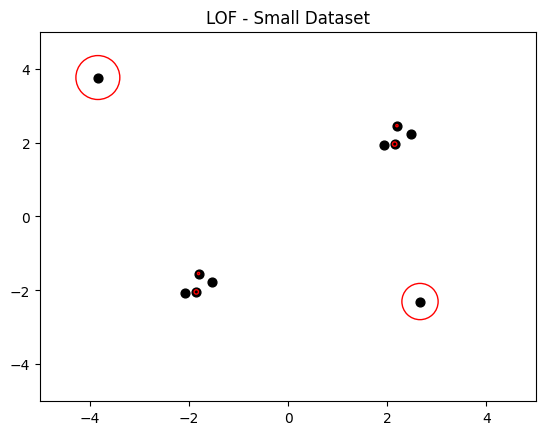

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

np.random.seed(42)

# Generate small train data
X_inliers = 0.3 * np.random.randn(4, 2)
X_inliers = np.r_[X_inliers + 2, X_inliers - 2]

# Generate outliers
X_outliers = np.random.uniform(low=-4, high=4, size=(2, 2))

# Combine data
X = np.r_[X_inliers, X_outliers]

n_outliers = len(X_outliers)

ground_truth = np.ones(len(X), dtype=int)
ground_truth[-n_outliers:] = -1

# LOF model
clf = LocalOutlierFactor(n_neighbors=3, contamination=0.2)

y_pred = clf.fit_predict(X)

X_scores = clf.negative_outlier_factor_

# Plot
plt.title("LOF - Small Dataset")

plt.scatter(X[:,0], X[:,1], color="black", s=40)

radius = (X_scores.max() - X_scores) / (X_scores.max() - X_scores.min())

plt.scatter(
    X[:,0],
    X[:,1],
    s=1000 * radius,
    edgecolors="red",
    facecolors="none"
)

plt.xlim(-5,5)
plt.ylim(-5,5)
plt.show()

8B (Large Dataset)

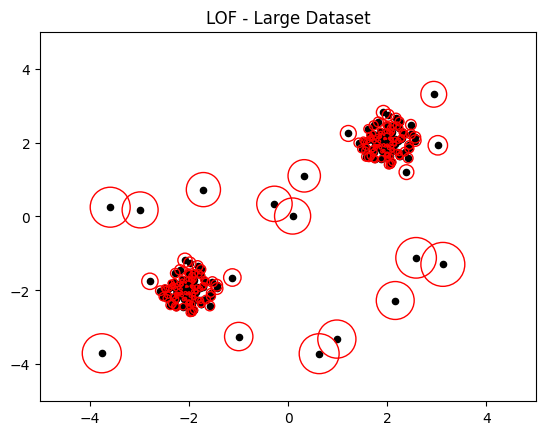

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

np.random.seed(42)

# Generate large dataset
X_inliers = 0.3 * np.random.randn(100, 2)
X_inliers = np.r_[X_inliers + 2, X_inliers - 2]

# Generate more outliers
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))

X = np.r_[X_inliers, X_outliers]

n_outliers = len(X_outliers)

ground_truth = np.ones(len(X), dtype=int)
ground_truth[-n_outliers:] = -1

clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)

y_pred = clf.fit_predict(X)

X_scores = clf.negative_outlier_factor_

plt.title("LOF - Large Dataset")

plt.scatter(X[:,0], X[:,1], color="black", s=20)

radius = (X_scores.max() - X_scores) / (X_scores.max() - X_scores.min())

plt.scatter(
    X[:,0],
    X[:,1],
    s=1000 * radius,
    edgecolors="red",
    facecolors="none"
)

plt.xlim(-5,5)
plt.ylim(-5,5)

plt.show()

8B (Multiple Neighbor Values)

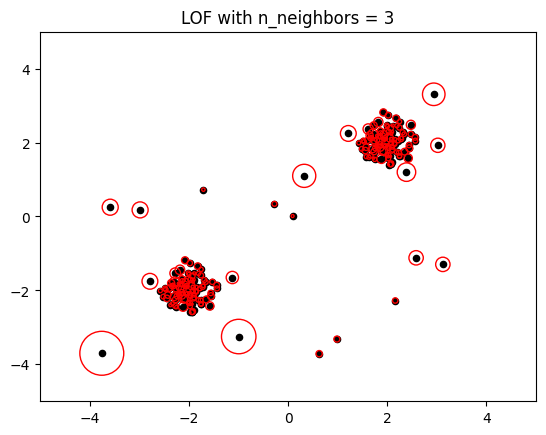

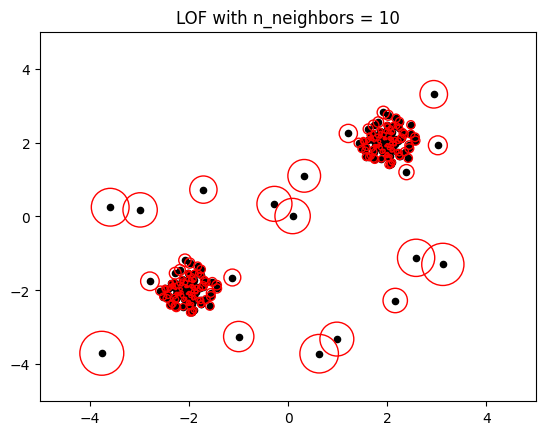

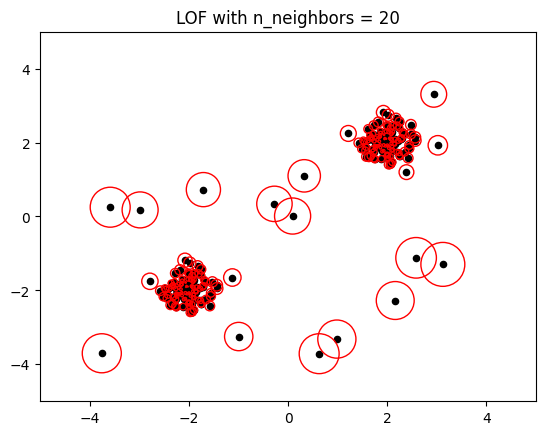

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

np.random.seed(42)

# Dataset
X_inliers = 0.3 * np.random.randn(100, 2)
X_inliers = np.r_[X_inliers + 2, X_inliers - 2]

X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))

X = np.r_[X_inliers, X_outliers]

neighbors_list = [3, 10, 20]

for k in neighbors_list:

    clf = LocalOutlierFactor(n_neighbors=k, contamination=0.1)
    y_pred = clf.fit_predict(X)
    X_scores = clf.negative_outlier_factor_

    plt.figure()

    plt.title("LOF with n_neighbors = " + str(k))

    plt.scatter(X[:,0], X[:,1], color="black", s=20)

    radius = (X_scores.max() - X_scores) / (X_scores.max() - X_scores.min())

    plt.scatter(
        X[:,0],
        X[:,1],
        s=1000 * radius,
        edgecolors="red",
        facecolors="none"
    )

    plt.xlim(-5,5)
    plt.ylim(-5,5)

    plt.show()

8C Demonstrate K-Nearest Neighbour Classifier

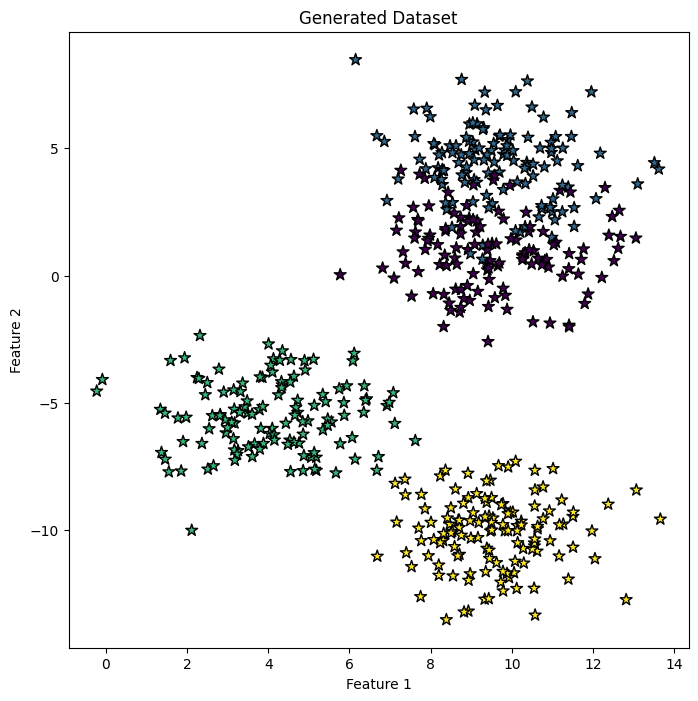

Accuracy with k=5: 93.60000000000001
Accuracy with k=1: 90.4


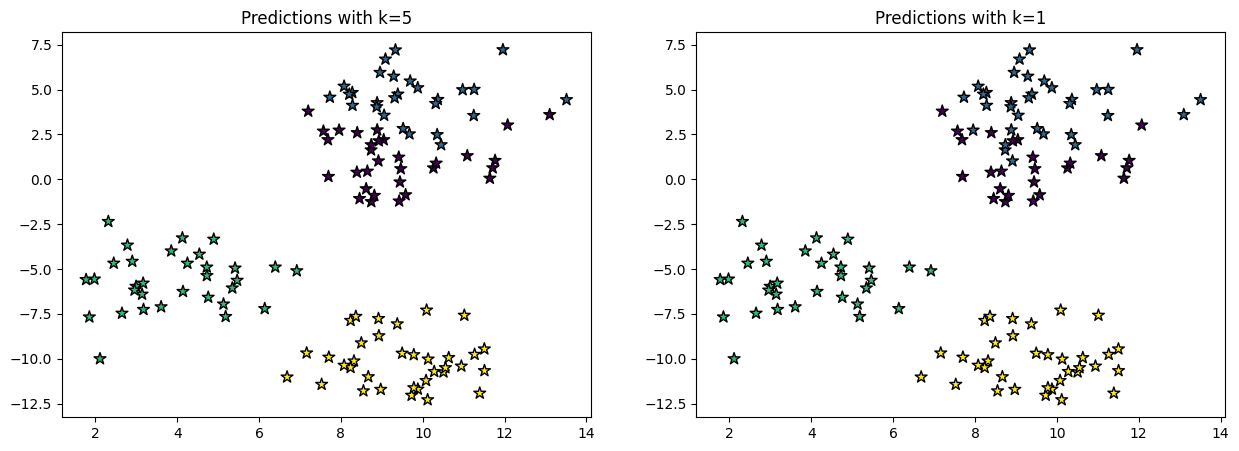

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Generate dataset
X, y = make_blobs(n_samples=500, n_features=2, centers=4,
                  cluster_std=1.5, random_state=4)

# Plot dataset
plt.figure(figsize=(8,8))
plt.scatter(X[:,0], X[:,1], c=y, marker='*', s=80, edgecolors='black')
plt.title("Generated Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

# Create models
knn5 = KNeighborsClassifier(n_neighbors=5)
knn1 = KNeighborsClassifier(n_neighbors=1)

# Train models
knn5.fit(X_train, y_train)
knn1.fit(X_train, y_train)

# Predictions
y_pred_5 = knn5.predict(X_test)
y_pred_1 = knn1.predict(X_test)

# Accuracy
print("Accuracy with k=5:", accuracy_score(y_test, y_pred_5)*100)
print("Accuracy with k=1:", accuracy_score(y_test, y_pred_1)*100)

# Plot predictions
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_5,
            marker='*', s=80, edgecolors='black')
plt.title("Predictions with k=5")

plt.subplot(1,2,2)
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_1,
            marker='*', s=80, edgecolors='black')
plt.title("Predictions with k=1")

plt.show()

8D KNN Algorithm for K = 1,3,5,9,11,13 and compare accuracy

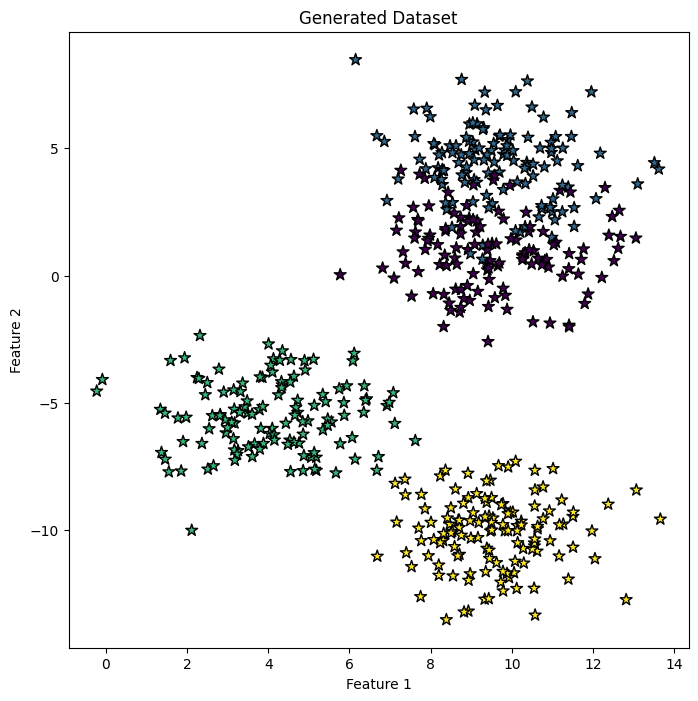

KNN Accuracy Comparison

Accuracy for k = 1 : 90.4
Accuracy for k = 3 : 92.80000000000001
Accuracy for k = 5 : 93.60000000000001
Accuracy for k = 9 : 94.39999999999999
Accuracy for k = 11 : 94.39999999999999
Accuracy for k = 13 : 93.60000000000001


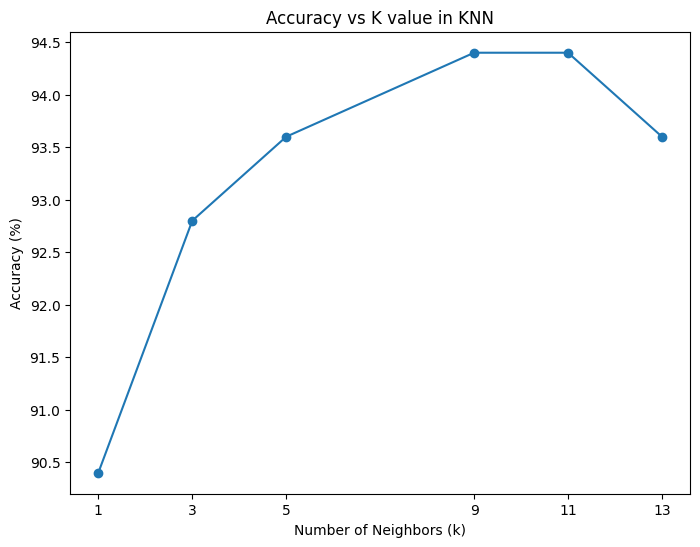

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Generate dataset
X, y = make_blobs(n_samples=500, n_features=2, centers=4,
                  cluster_std=1.5, random_state=4)

# Plot original dataset
plt.figure(figsize=(8,8))
plt.scatter(X[:,0], X[:,1], c=y, marker='*', s=80, edgecolors='black')
plt.title("Generated Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

# Different k values
k_values = [1,3,5,9,11,13]

accuracies = []

print("KNN Accuracy Comparison\n")

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred) * 100
    accuracies.append(acc)

    print("Accuracy for k =", k, ":", acc)

# Plot accuracy vs k
plt.figure(figsize=(8,6))
plt.plot(k_values, accuracies, marker='o')

plt.title("Accuracy vs K value in KNN")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy (%)")

plt.xticks(k_values)

plt.show()